# House Price Prediction

A reproducible Ames housing price workflow. The notebook evaluates four regression models using identical shuffled 7-fold cross-validation. Imputation and encoding are fitted within each fold; numeric scaling is applied only to Linear Regression, KNN, and SVR. Gradient Boosting is selected only when its measured CV performance ranks highest.

## Notebook Sections
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
4. Data Cleaning
5. Missing Value Handling
6. Feature Engineering
7. Encoding / Transformation
8. Train-Validation Split
9. Model 1 — Linear Regression
10. Model 2 — KNN Regression
11. Model 3 — Support Vector Regression
12. Model 4 — Gradient Boosting Regression
13. Model Comparison
14. Final Model Selection
15. Final Prediction
16. Generate Submission File

Run the single code cell below from top to bottom. It creates fresh model artifacts, `submission.csv`, and `model_evaluation_report.txt`.

Training rows: 1,460; test rows: 1,459; training features: 79


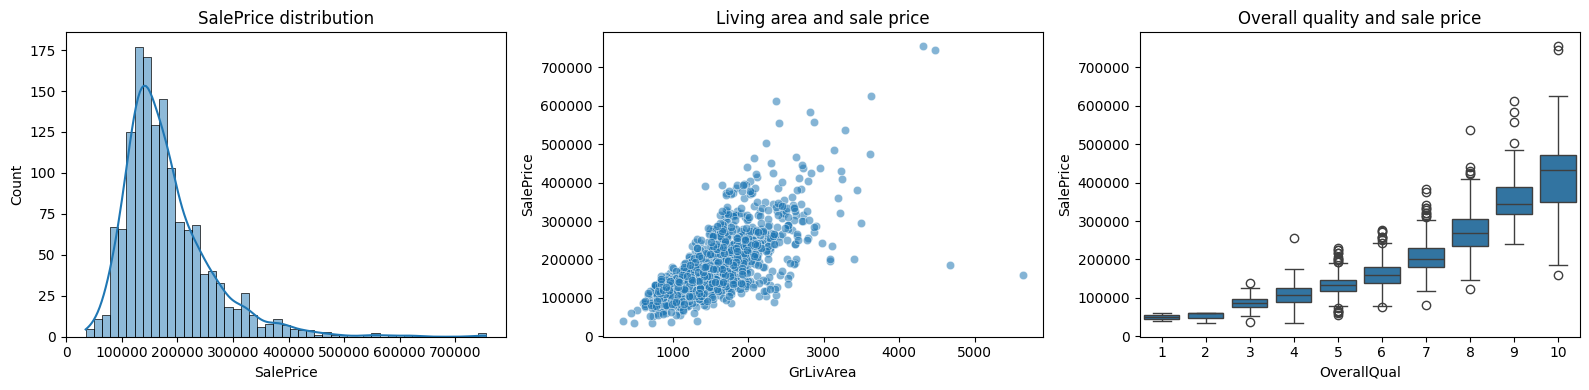

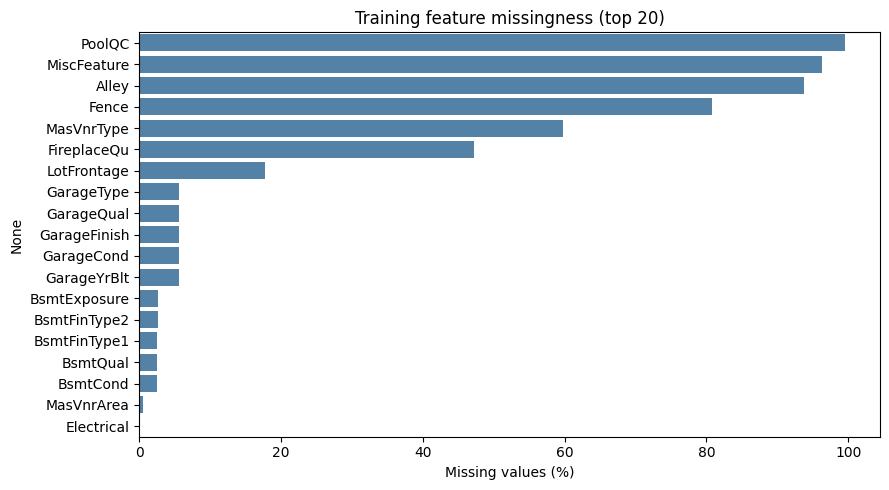

Numeric features most correlated with SalePrice:


,absolute correlation
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


,Model,R2,MAE,RMSE,CV R2,CV R2 std,CV MAE,CV RMSE
0,Gradient Boosting,0.8776,16281.8827,27784.8306,0.8674,0.0734,16281.0401,27417.3199
1,KNN Regressor,0.7546,21767.7616,39342.5864,0.7503,0.0831,21768.2212,38817.9204
2,Linear Regression,0.6408,19600.8240,47597.5216,0.6003,0.4564,19602.7646,43246.2686
3,SVR,-0.0493,55504.6484,81350.6783,-0.0513,0.0155,55508.5742,80928.9770


Selected model: Gradient Boosting (highest mean 7-fold CV R2; OOF RMSE breaks ties).
Multiple regression models were evaluated, and Gradient Boosting Regressor was selected as the final model based on comparative performance.
Saved four reload-checked models in c:\Users\Sathw\Downloads\House-Price-Prediction-Updated\House-Price-Prediction-master\ML_Model\src
Saved validated submission: c:\Users\Sathw\Downloads\House-Price-Prediction-Updated\House-Price-Prediction-master\ML_Model\src\submission.csv (1459 rows)
Saved evaluation report: c:\Users\Sathw\Downloads\House-Price-Prediction-Updated\House-Price-Prediction-master\model_evaluation_report.txt


In [3]:
# 1. Import Libraries
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

RANDOM_STATE = 45
N_SPLITS = 7

# 2. Load Dataset
cwd = Path.cwd()
source_dir = next(
    (path for path in [cwd, *(parent / "ML_Model" / "src" for parent in [cwd, *cwd.parents]),
                       *(parent for parent in cwd.parents)]
     if (path / "main.ipynb").is_file()
     and (path.parent / "data_set" / "train.csv").is_file()),
    None,
)
if source_dir is None:
    raise FileNotFoundError("Could not locate ML_Model/src/main.ipynb and data_set/train.csv from the current directory.")
data_dir = source_dir.parent / "data_set"
project_dir = source_dir.parent.parent
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")

TARGET = "SalePrice"
if TARGET not in train or "Id" not in train or "Id" not in test:
    raise ValueError("Expected Id in both datasets and SalePrice in train.csv.")
if train["Id"].duplicated().any() or test["Id"].duplicated().any():
    raise ValueError("Dataset IDs must be unique.")

# 3. Exploratory Data Analysis
print(f"Training rows: {len(train):,}; test rows: {len(test):,}; training features: {train.shape[1] - 2}")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(train[TARGET], kde=True, ax=axes[0])
axes[0].set_title("SalePrice distribution")
sns.scatterplot(data=train, x="GrLivArea", y=TARGET, alpha=0.55, ax=axes[1])
axes[1].set_title("Living area and sale price")
sns.boxplot(data=train, x="OverallQual", y=TARGET, ax=axes[2])
axes[2].set_title("Overall quality and sale price")
plt.tight_layout()
plt.show()
missing = train.drop(columns=TARGET).isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0].head(20)
if not missing.empty:
    plt.figure(figsize=(9, 5))
    sns.barplot(x=missing.values, y=missing.index, color="steelblue")
    plt.xlabel("Missing values (%)")
    plt.title("Training feature missingness (top 20)")
    plt.tight_layout()
    plt.show()
correlations = train.select_dtypes(include=np.number).corr(numeric_only=True)[TARGET]
print("Numeric features most correlated with SalePrice:")
display(correlations.drop(TARGET).abs().sort_values(ascending=False).head(10).to_frame("absolute correlation"))

# 4. Data Cleaning
# Keep rows and source features; remove the identifier from model inputs.
X = train.drop(columns=[TARGET, "Id"]).copy()
y = train[TARGET].copy()
test_ids = test["Id"].copy()
X_test = test.drop(columns="Id").copy()
if list(X.columns) != list(X_test.columns):
    raise ValueError("Train and test feature columns do not match.")

# 5. Missing Value Handling
# Imputers are inside each model pipeline, so every CV fold learns from its training fold only.

# 6. Feature Engineering
# Preserve the provided Kaggle feature set; Id is excluded because it is only a row identifier.

# 7. Encoding / Transformation
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

def make_preprocessor(scale_features=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_features:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipeline = Pipeline(numeric_steps)
    categorical_steps = [
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
    categorical_pipeline = Pipeline(categorical_steps)
    return ColumnTransformer(
        [("numeric", numeric_pipeline, numeric_features),
         ("categorical", categorical_pipeline, categorical_features)],
        remainder="drop",
    )

# 8. Train-Validation Split
# The same shuffled seven-fold split is reused for every model.
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# 9. Model 1 — Linear Regression
# 10. Model 2 — KNN Regression
# 11. Model 3 — Support Vector Regression
# 12. Model 4 — Gradient Boosting Regression
model_specs = {
    "Linear Regression": (LinearRegression(), True),
    "KNN Regressor": (KNeighborsRegressor(), True),
    "SVR": (SVR(), True),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=RANDOM_STATE), False),
}

# 13. Model Comparison
# Each fold fits its own imputation/encoding/scaling and contributes OOF predictions and scores.
results = []
oof_predictions = {}
for model_name, (estimator, scale_features) in model_specs.items():
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor(scale_features)),
        ("regressor", estimator),
    ])
    predictions = np.full(len(X), np.nan)
    fold_r2, fold_mae, fold_rmse = [], [], []
    for train_indices, validation_indices in cv.split(X, y):
        fold_model = clone(pipeline)
        fold_model.fit(X.iloc[train_indices], y.iloc[train_indices])
        fold_prediction = fold_model.predict(X.iloc[validation_indices])
        predictions[validation_indices] = fold_prediction
        validation_target = y.iloc[validation_indices]
        fold_r2.append(r2_score(validation_target, fold_prediction))
        fold_mae.append(mean_absolute_error(validation_target, fold_prediction))
        fold_rmse.append(np.sqrt(mean_squared_error(validation_target, fold_prediction)))
    if np.isnan(predictions).any():
        raise RuntimeError(f"Cross-validation did not predict every row for {model_name}.")
    oof_predictions[model_name] = predictions
    results.append({
        "Model": model_name,
        "R2": r2_score(y, predictions),
        "MAE": mean_absolute_error(y, predictions),
        "RMSE": np.sqrt(mean_squared_error(y, predictions)),
        "CV R2": float(np.mean(fold_r2)),
        "CV R2 std": float(np.std(fold_r2, ddof=1)),
        "CV MAE": float(np.mean(fold_mae)),
        "CV RMSE": float(np.mean(fold_rmse)),
    })
comparison = pd.DataFrame(results).sort_values(
    ["CV R2", "RMSE"], ascending=[False, True], ignore_index=True
)
display(comparison.round(4))

# 14. Final Model Selection
# Select highest mean seven-fold CV R2; use pooled OOF RMSE as the tie-breaker.
best_model_name = comparison.iloc[0]["Model"]
print(f"Selected model: {best_model_name} (highest mean 7-fold CV R2; OOF RMSE breaks ties).")
if best_model_name == "Gradient Boosting":
    print("Multiple regression models were evaluated, and Gradient Boosting Regressor was selected as the final model based on comparative performance.")
else:
    print("Gradient Boosting was not the top performer in this evaluation; the highest-ranked model is used for final predictions.")

# Retrain all four complete pipelines on all training rows and save fresh artifacts.
artifact_names = {
    "Linear Regression": "linear_regression_model.pkl",
    "KNN Regressor": "knn_regressor_model.pkl",
    "SVR": "svm_regressor_model.pkl",
    "Gradient Boosting": "gbr.pkl",
}
final_models = {}
for model_name, (estimator, scale_features) in model_specs.items():
    final_pipeline = Pipeline([
        ("preprocessor", make_preprocessor(scale_features)),
        ("regressor", clone(estimator)),
    ])
    final_pipeline.fit(X, y)
    artifact_path = source_dir / artifact_names[model_name]
    joblib.dump(final_pipeline, artifact_path)
    loaded_pipeline = joblib.load(artifact_path)
    if not np.allclose(final_pipeline.predict(X.iloc[:5]), loaded_pipeline.predict(X.iloc[:5])):
        raise RuntimeError(f"Saved model failed its reload check: {artifact_path.name}")
    final_models[model_name] = loaded_pipeline

# 15. Final Prediction
final_predictions = final_models[best_model_name].predict(X_test)

# 16. Generate Submission File
submission = pd.DataFrame({"Id": test_ids, "SalePrice": final_predictions})
submission_path = source_dir / "submission.csv"
submission.to_csv(submission_path, index=False)
submission_check = pd.read_csv(submission_path)
assert len(submission_check) == len(test) == 1459
assert submission_check["SalePrice"].notna().all()
assert pd.api.types.is_numeric_dtype(submission_check["SalePrice"])
assert submission_check["Id"].is_unique
assert submission_check["Id"].tolist() == test_ids.tolist()

# Save a fresh evaluation report from the computed results.
report_path = project_dir / "model_evaluation_report.txt"
report_lines = [
    "House Price Prediction: 7-Fold Cross-Validation Results",
    "=======================================================",
    f"Selected model: {best_model_name}",
    "R2, MAE, and RMSE are computed from pooled out-of-fold predictions.",
    "CV R2 and CV errors are the unweighted mean of the seven validation folds.",
    "",
    comparison[["Model", "R2", "MAE", "RMSE", "CV R2"]].to_string(index=False, float_format=lambda value: f"{value:.6f}"),
    "",
    f"Submission rows: {len(submission_check)}",
    f"Submission file: ML_Model/src/{submission_path.name}",
]
report_path.write_text("\n".join(report_lines) + "\n", encoding="utf-8")
print(f"Saved four reload-checked models in {source_dir}")
print(f"Saved validated submission: {submission_path} ({len(submission_check)} rows)")
print(f"Saved evaluation report: {report_path}")

In [4]:
# Include MSE explicitly alongside the requested comparison metrics.
comparison.insert(
    comparison.columns.get_loc("RMSE"),
    "MSE",
    [mean_squared_error(y, oof_predictions[name]) for name in comparison["Model"]],
)
display(comparison[["Model", "R2", "MAE", "MSE", "RMSE", "CV R2"]].round(4))

report_lines = [
    "House Price Prediction: 7-Fold Cross-Validation Results",
    "=======================================================",
    f"Selected model: {best_model_name}",
    "R2, MAE, MSE, and RMSE are computed from pooled out-of-fold predictions.",
    "CV R2 is the unweighted mean of the seven validation-fold R2 values.",
    "R2 percentage is a regression score, not classification accuracy.",
    "",
    "R2 score by model:",
    *[f"{row['Model']}: {row['R2']:.2%}" for _, row in comparison.iterrows()],
    "",
    comparison[["Model", "R2", "MAE", "MSE", "RMSE", "CV R2"]].to_string(
        index=False, float_format=lambda value: f"{value:.6f}"
    ),
    "",
    f"Submission rows: {len(submission_check)}",
    f"Submission file: ML_Model/src/{submission_path.name}",
]
report_path.write_text("\n".join(report_lines) + "\n", encoding="utf-8")

,Model,R2,MAE,MSE,RMSE,CV R2
0,Gradient Boosting,0.8776,16281.8827,7.719968e+08,27784.8306,0.8674
1,KNN Regressor,0.7546,21767.7616,1.547839e+09,39342.5864,0.7503
2,Linear Regression,0.6408,19600.8240,2.265524e+09,47597.5216,0.6003
3,SVR,-0.0493,55504.6484,6.617933e+09,81350.6783,-0.0513


939